## Penguin - Machine Learning - Multi Model Predction

## Exploratory Data Analysis

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

sns.set_style('whitegrid')

if os.getcwd() == "d:\Innomatics\Git_Uploads\penguin-ml-multi_model_prediction\sciripts":
    os.chdir("..")
print("Cuurent Directory:",os.getcwd())

Cuurent Directory: d:\Innomatics\Git_Uploads\penguin-ml-multi_model_prediction


In [3]:
df = pd.read_csv("data/penguins_size.csv")
df.sample(5)

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
119,Adelie,Torgersen,41.1,18.6,189.0,3325.0,MALE
332,Gentoo,Biscoe,43.5,15.2,213.0,4650.0,FEMALE
103,Adelie,Biscoe,37.8,20.0,190.0,4250.0,MALE
165,Chinstrap,Dream,52.0,18.1,201.0,4050.0,MALE
254,Gentoo,Biscoe,49.1,14.8,220.0,5150.0,FEMALE


In [4]:
df.shape

(344, 7)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    str    
 1   island             344 non-null    str    
 2   culmen_length_mm   342 non-null    float64
 3   culmen_depth_mm    342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                334 non-null    str    
dtypes: float64(4), str(3)
memory usage: 24.9 KB


In [6]:
df.describe()

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g
count,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,200.915205,4201.754386
std,5.459584,1.974793,14.061714,801.954536
min,32.100000,13.100000,172.000000,2700.000000
25%,39.225000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000


In [16]:
df.describe(include="object")

,species,island,sex
count,344,344,334
unique,3,3,3
top,Adelie,Biscoe,MALE
freq,152,168,168


In [17]:
df["species"].value_counts()

species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64

In [18]:
df["sex"].value_counts()

sex
MALE      168
FEMALE    165
.           1
Name: count, dtype: int64

In [25]:
df.isnull().sum()

species               0
island                0
culmen_length_mm      2
culmen_depth_mm       2
flipper_length_mm     2
body_mass_g           2
sex                  10
dtype: int64

In [21]:
df[df.isnull().any(axis=1)]

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
8,Adelie,Torgersen,34.1,18.1,193.0,3475.0,NaN
9,Adelie,Torgersen,42.0,20.2,190.0,4250.0,NaN
10,Adelie,Torgersen,37.8,17.1,186.0,3300.0,NaN
11,Adelie,Torgersen,37.8,17.3,180.0,3700.0,NaN
47,Adelie,Dream,37.5,18.9,179.0,2975.0,NaN
246,Gentoo,Biscoe,44.5,14.3,216.0,4100.0,NaN
286,Gentoo,Biscoe,46.2,14.4,214.0,4650.0,NaN
324,Gentoo,Biscoe,47.3,13.8,216.0,4725.0,NaN
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN


In [22]:
## Here two rows are completely null so we will drop them

Text(0.5, 1.0, 'Distribution of Species')

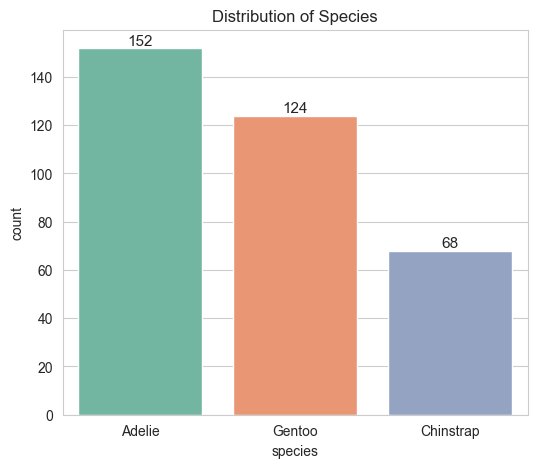

In [46]:
plt.figure(figsize=(6,5))
ax = sns.countplot(data=df,x="species",palette="Set2",order=df["species"].value_counts().index)
for p in ax.patches:
    ax.annotate(int(p.get_height()),(p.get_x() + p.get_width()/2.,p.get_height()),
                    ha="center",va="bottom",fontsize = 11)
plt.title("Distribution of Species")

In [7]:
## there is huge imbalance between the classes

## Univariate Analysis

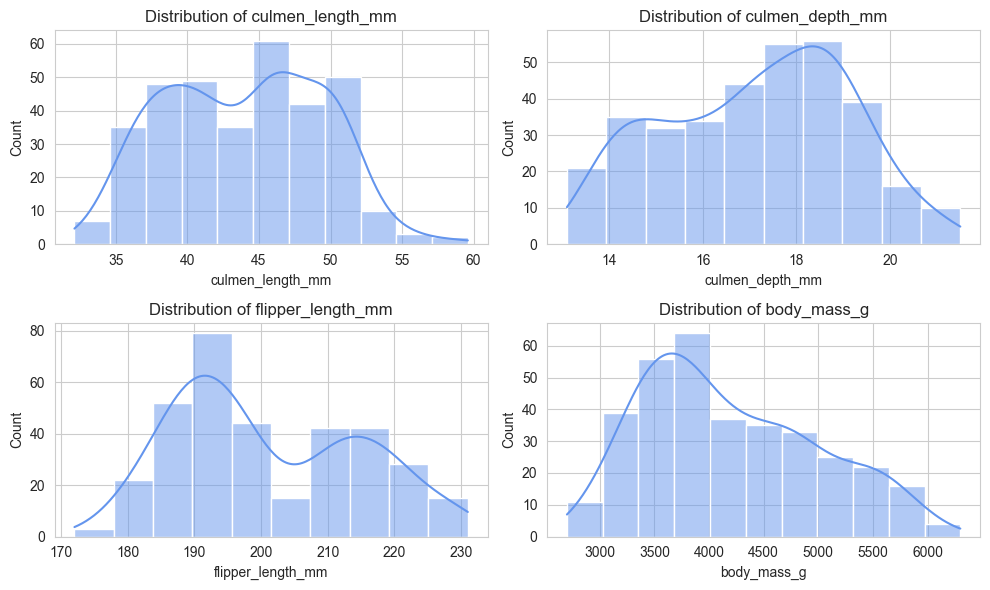

In [11]:
num_cols = ["culmen_length_mm","culmen_depth_mm","flipper_length_mm","body_mass_g"]
fig,axes = plt.subplots(2,2, figsize = (10,6))

for ax, col in zip(axes.flat,num_cols):
    sns.histplot(data = df,x=col,ax=ax,kde = True,color = "cornflowerblue")
    ax.set_title(f"Distribution of {col}")
plt.tight_layout()
plt.show()


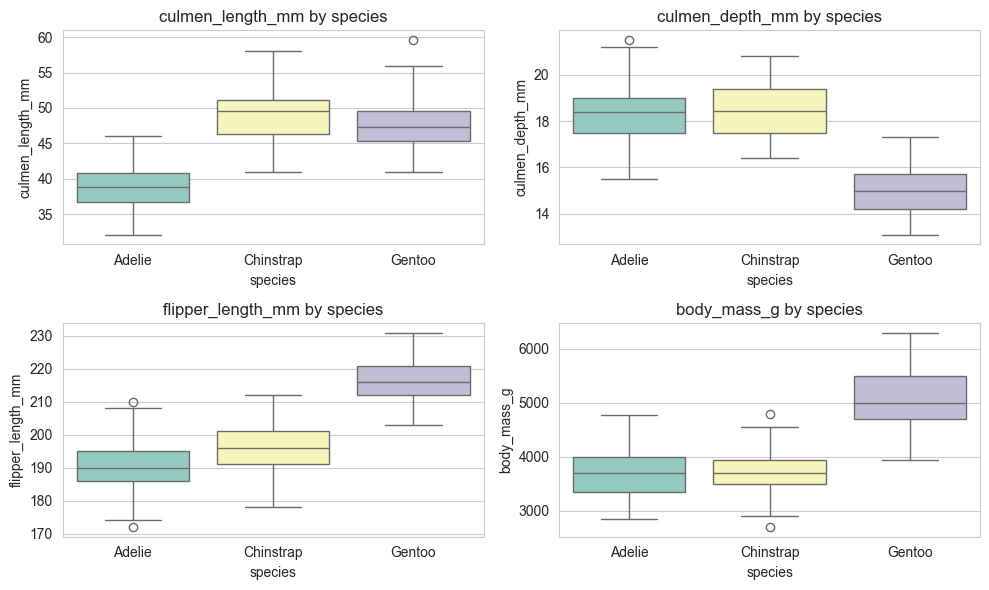

In [13]:
fig,axes = plt.subplots(2,2, figsize=(10,6))
for ax, col in zip(axes.flat,num_cols):
    sns.boxplot(data=df,x="species",y=col,ax=ax, palette = 'Set3')
    ax.set_title(f"{col} by species")
plt.tight_layout()
plt.show()

- From this, clearly we can see how we can differentiate the species based on just culmen lenght and depth combination.
- Gentoo stands out in body_mass and flipper length

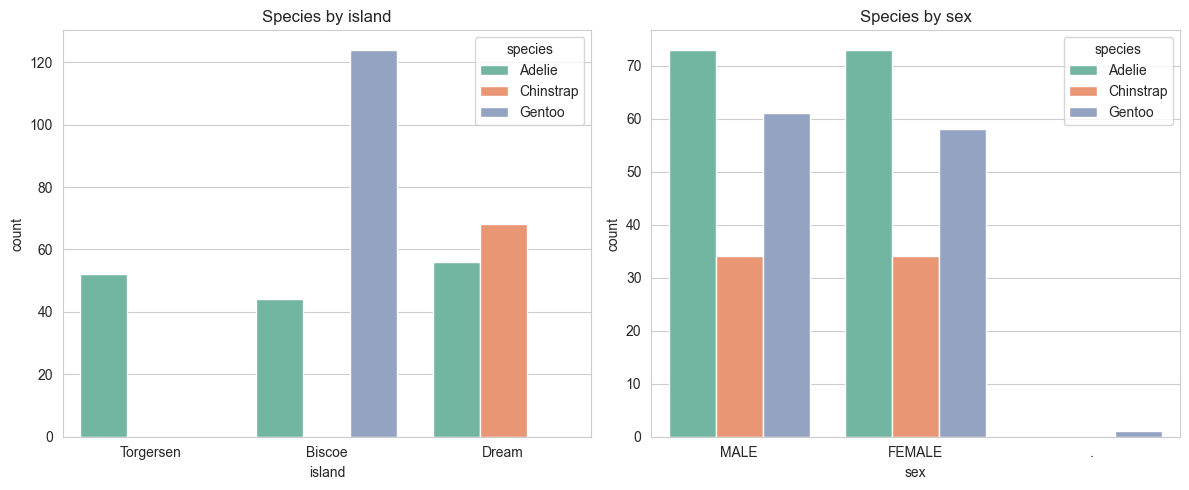

In [17]:
fig,axes = plt.subplots(1,2, figsize= (12,5))
sns.countplot(data=df,x='island',hue='species',ax=axes[0],palette='Set2')
axes[0].set_title('Species by island')
sns.countplot(data=df.dropna(subset=['sex']),x='sex',hue = 'species',ax=axes[1],palette='Set2')
axes[1].set_title('Species by sex')
plt.tight_layout()
plt.show()

In [18]:
pd.crosstab(df['island'],df['species'])

species,Adelie,Chinstrap,Gentoo
island,,,
Biscoe,44,0,124
Dream,56,68,0
Torgersen,52,0,0


#### Island is data leakage as Gentoo and Chnstrap is only in specific islands, so its polarized.

## Bi-variate Analysis

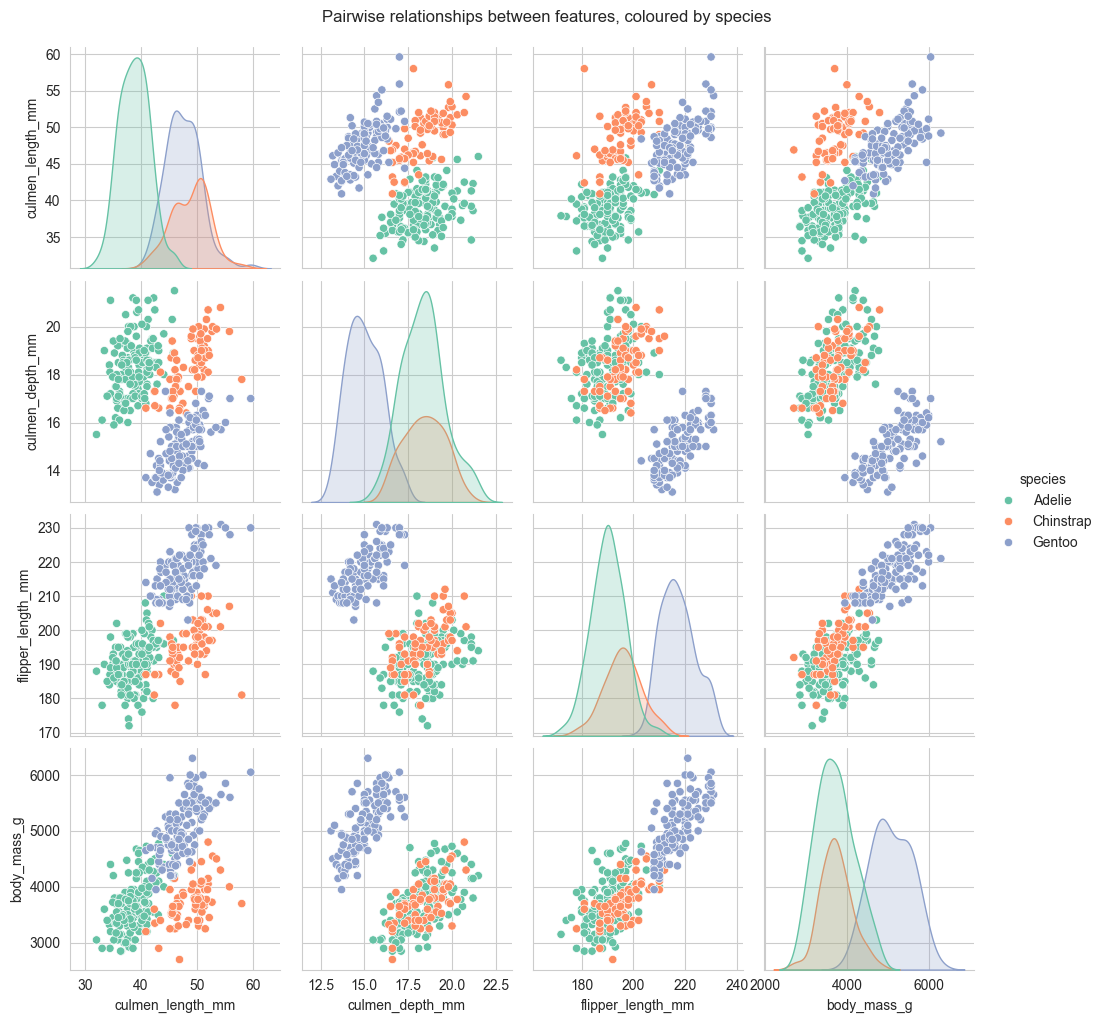

In [22]:
sns.pairplot(df.dropna(),hue='species',palette="Set2",diag_kind='kde')
plt.suptitle('Pairwise relationships between features, coloured by species', y=1.02)
plt.show()

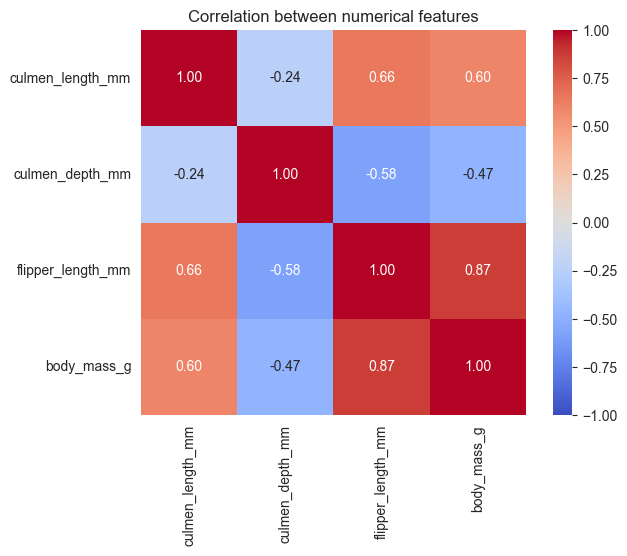

In [25]:
plt.figure(figsize=(7, 5))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f', square=True, vmin=-1, vmax=1)
plt.title('Correlation between numerical features')
plt.show()